### <span style="color:lightgreen"> Case Study 2: Sentiment Analysis for Customer Feedback </span>

Training samples: 25000, Testing samples: 25000
Shape after padding: (25000, 200)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.5006 - loss: 0.6973 - val_accuracy: 0.5053 - val_loss: 0.6933
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.5538 - loss: 0.6802 - val_accuracy: 0.5452 - val_loss: 0.6910
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.6576 - loss: 0.5587 - val_accuracy: 0.5398 - val_loss: 0.7783
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.7344 - loss: 0.4064 - val_accuracy: 0.5339 - val_loss: 0.9325
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.7444 - loss: 0.3787 - val_accuracy: 0.5170 - val_loss: 1.1623


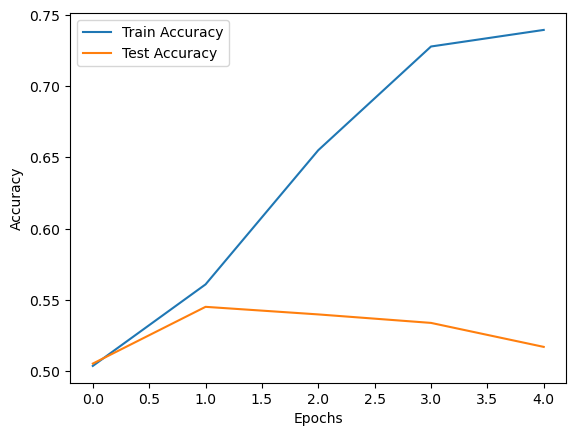

In [6]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import matplotlib.pyplot as plt


# Loading the Dataset in Python
num_words = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)

print(f"Training samples: {len(x_train)}, Testing samples: {len(x_test)}")

# Text Preprocessing for RNN
# Each review has a different length, we need to pad them to a fixed size.
max_length = 200  # Max words in a review
x_train = pad_sequences(x_train, maxlen=max_length, padding='post', truncating='post')
x_test = pad_sequences(x_test, maxlen=max_length, padding='post', truncating='post')

print(f"Shape after padding: {x_train.shape}")

# Building the Sentiment Analysis Model with RNN
'''
    Embedding Layer → Converts words into dense vectors.
    Simple RNN Layer → Captures sequential dependencies.
    Dense Layer → Outputs sentiment classification.
'''
model = Sequential([
    Embedding(input_dim=num_words, output_dim=64, input_length=max_length),
    SimpleRNN(64, return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary Classification (0 = Negative, 1 = Positive)
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Model Summary
model.summary()

# Train Model
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test))

# Visualizing Training Performance
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

model.save("sentiment_rnn.h5")